In [8]:
%load_ext autoreload
%autoreload 2

In [10]:
import os
from settings import OUTPUT_FOLDER
from data_generation import read_output
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

def get_inv_rank(evals):
    # evals: lista o array de scores de una sola muestra
    # 1. Ranking con manejo de empates (Competition ranking)
    sorted_evals = sorted(evals, reverse=True)
    ranking_dict = {}
    for j, ev in enumerate(sorted_evals):
        if ev not in ranking_dict:
            ranking_dict[ev] = j + 1
    
    # 2. Asignar ranking a cada acción
    ranks = np.array([ranking_dict[ev] for ev in evals], dtype=float)
    
    # 3. Invertir: 1/r
    return 1.0 / ranks

def get_kl_div_mean(folder_paths, tau=0.1):
    all_kl_divs = []

    for folder_path in folder_paths:
        full_path = OUTPUT_FOLDER / folder_path
        if not os.path.isdir(full_path):
            print(f"⚠️ Carpeta no encontrada: {full_path}")
            continue

        for filename in os.listdir(full_path):
            filepath = os.path.join(full_path, filename)
            _, _, _, _, _, _, _, greedy_evals_all, vcs_evals_all = read_output(filepath)
            
            for i in range(len(greedy_evals_all)):
                # Obtener rangos invertidos (1/r)
                gr_inv = get_inv_rank(greedy_evals_all[i])
                vcs_inv = get_inv_rank(vcs_evals_all[i])
                
                # Convertir a Tensores para usar las funciones de PyTorch (más fácil y consistente)
                # Softmax con Temperatura para ambos
                p_greedy = F.softmax(torch.tensor(gr_inv) / tau, dim=-1)
                p_vcs = F.softmax(torch.tensor(vcs_inv) / tau, dim=-1)
                
                # KL Divergence: F.kl_div espera (log_p_pred, p_target)
                # Aquí comparamos qué tan lejos está VCS de Greedy
                kl = F.kl_div(p_vcs.log(), p_greedy, reduction='sum')
                
                all_kl_divs.append(kl.item())

    if not all_kl_divs:
        return 0.0
        
    mean_kl = np.mean(all_kl_divs)
    print(f"📊 KL Divergence Media (Greedy vs VCS): {mean_kl:.6f}")
    return mean_kl

In [8]:
folders = ["E8-1"]

get_kl_div_mean(folders, tau=0.1)

📊 KL Divergence Media (Greedy vs VCS): 4.321265


np.float64(4.321265283898213)

In [30]:
import os
from settings import OUTPUT_FOLDER
from data_generation import read_output
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def get_max_position_distribution(folder_paths):
    """
    Calcula la frecuencia con la que el máximo valor de Greedy 
    aparece en cada posición del ranking (ya ordenado por VCS).
    """
    counter = {}

    for folder_path in folder_paths:
        full_path = OUTPUT_FOLDER / folder_path
        if not os.path.isdir(full_path):
            print(f"⚠️ Carpeta no encontrada: {full_path}")
            continue

        for filename in os.listdir(full_path):
            filepath = os.path.join(full_path, filename)
            
            # Solo necesitamos greedy_evals_all porque ya está ordenado por VCS
            _, _, _, _, _, _, _, greedy_evals_all, _ = read_output(filepath)
            
            for evals in greedy_evals_all:
                gr_evs = np.array(evals)

                # 1. Hallamos el valor máximo que el experto (Greedy) asignó
                max_greedy_val = np.max(gr_evs)
                
                # 2. Buscamos su primera posición (0-indexed)
                # Como el arreglo ya está ordenado por VCS, el índice nos da directamente la posición
                pos_idx = np.where(gr_evs == max_greedy_val)[0][0]
                
                # 3. Convertimos a 1-based (Posición 1, 2, 3...)
                pos_vcs = pos_idx + 1
                
                # 4. Actualizamos contador
                counter[pos_vcs] = counter.get(pos_vcs, 0) + 1

    if not counter:
        return []

    # Construimos el arreglo final desde la posición 1 hasta la máxima encontrada
    max_pos = max(counter.keys())
    arr_counter = [counter.get(i, 0) for i in range(1, max_pos + 1)]
    
    return arr_counter

def plot_ranking_frequencies(counters_dict):
    """
    Superpone uno o más contadores de frecuencia de ranking.
    
    Args:
        counters_dict (dict): { 'Nombre Serie': [lista_frecuencias], ... }
    """
    plt.figure(figsize=(10, 6), dpi=100)
    
    # Colores consistentes para las comparaciones
    colors = plt.cm.tab10(np.linspace(0, 1, len(counters_dict)))

    for (label, counter), color in zip(counters_dict.items(), colors):
        # 1. Preparar ejes
        positions = np.arange(1, len(counter) + 1)
        
        # 2. Calcular frecuencia acumulada porcentual
        cum_freq = np.cumsum(counter)
        total = cum_freq[-1]
        cum_percent = (cum_freq / total) * 100

        # 3. Graficar
        plt.plot(positions, cum_percent, label=f"{label} (Top-1: {cum_percent[0]:.1f}%)", 
                 linewidth=2, color=color, marker='o', markersize=3, markevery=5)

    # Configuración de estilo
    plt.xlabel("Posición en el Ranking", fontsize=12)
    plt.ylabel("Frecuencia Acumulada (%)", fontsize=12)
    plt.title("Comparación de Calidad de Ranking: Heurística vs. Modelo", fontsize=14, pad=15)
    
    # Límites y rejilla
    plt.ylim(0, 105)
    plt.xlim(0, max([len(c) for c in counters_dict.values()]) + 2)
    plt.grid(True, linestyle="--", alpha=0.5)
    
    # Leyenda para identificar cada curva
    plt.legend(loc="lower right", frameon=True, shadow=True)
    
    plt.tight_layout()
    plt.show()

def get_frequency_dataframe(counter):
    result = [(i, counter[i - 1]) for i in range(1, len(counter) + 1)]
    df = pd.DataFrame(result, columns=["Posición", "Frecuencia"])

    total = df["Frecuencia"].sum()
    df["Frecuencia (%)"] = df["Frecuencia"] / total * 100
    df["Frecuencia acumulada"] = np.cumsum(df["Frecuencia"])
    df["Frecuencia acumulada (%)"] = df["Frecuencia acumulada"] / total * 100

    # Orden final de columnas
    df = df[[
        "Posición",
        "Frecuencia (%)",
        "Frecuencia acumulada (%)"
    ]]

    return df

In [49]:
folders = ["BR8"]

vcs_gr_counter = get_max_position_distribution(folders)

In [ ]:
df = get_frequency_dataframe(vcs_gr_counter)
df.head(10)

,Posición,Frecuencia (%),Frecuencia acumulada (%)
0,1,53.843680,53.843680
1,2,5.660984,59.504664
2,3,3.795433,63.300096
3,4,2.605339,65.905436
4,5,2.830492,68.735928
5,6,1.994210,70.730138
6,7,1.608234,72.338372
7,8,1.736893,74.075265
8,9,0.578964,74.654230
9,10,0.771952,75.426182


In [40]:
from models.CLPTransformer_v7 import CLPTransformer
from training import load_model

model_name = "CLPTransformer_v7_1_ACL"

model = load_model(CLPTransformer, model_name)

In [53]:
from models.base.transformer import Transformer
from data_preprocessing import load_data
from torch.utils.data import DataLoader
import numpy as np

def validation(model: Transformer, filename: str):
    data = load_data(filename)

    preds = get_preds(model, data)
    y = np.array(data.Y)

    counter = {}
        
    for i in range(len(preds)):
        # Ordenar los índices de las predicciones del modelo de mejor a peor
        # argsort de -preds nos da los índices en orden descendente
        model_sorted_indices = np.argsort(-preds[i])
        
        # Encontrar el valor máximo del experto (Greedy)
        max_y_val = np.max(y[i])
        # Encontrar la posición (índice original) de la mejor acción según el experto
        best_action_idx = np.where(y[i] == max_y_val)[0][0]
        
        # Ver en qué posición del ranking del modelo quedó esa acción experta
        # Buscamos el índice original dentro del ranking ordenado por el modelo
        pos_in_model = np.where(model_sorted_indices == best_action_idx)[0][0] + 1
        
        # Guardar en el diccionario
        counter[pos_in_model] = counter.get(pos_in_model, 0) + 1

    # Generar el arreglo de frecuencias acumuladas
    if not counter:
        return []

    max_pos = max(counter.keys())
    arr_counter = [counter.get(i, 0) for i in range(1, max_pos + 1)]

    return arr_counter

def get_preds(model: Transformer, data):
    model.eval()
    loader = DataLoader(data, batch_size=1) 

    preds = []
    with torch.no_grad():
        for batch in loader:
            *inputs, y_batch = [i for i in batch]
            logits = model(*inputs)
            preds.append(logits.squeeze())
    
    return np.array(preds)

model_gr_counter = validation(model, "BR8.data")

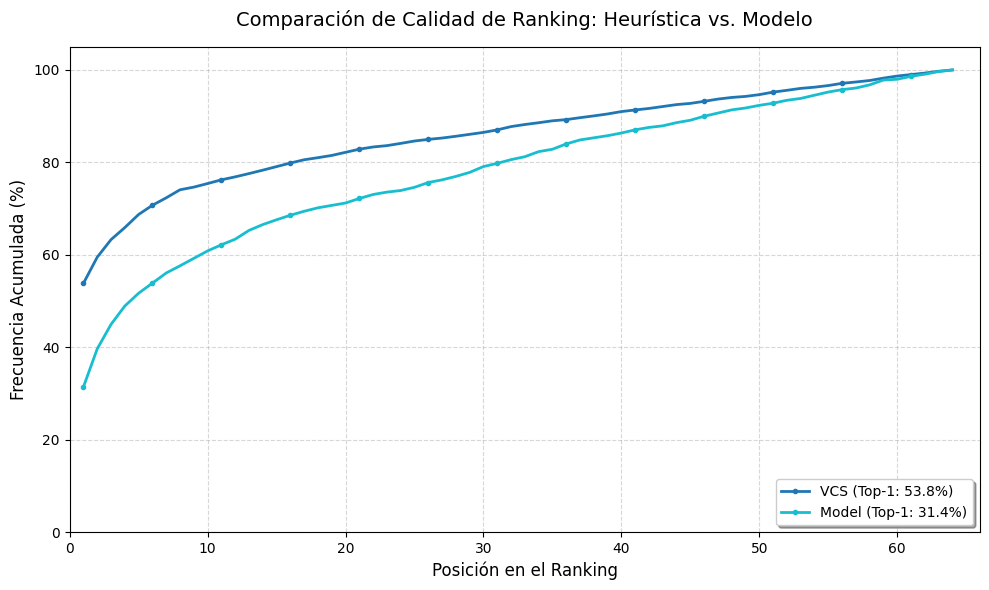

In [52]:
counters = {
    "VCS": vcs_gr_counter,
    "Model": model_gr_counter
}

plot_ranking_frequencies(counters)

In [43]:
def get_ranking_frequencies(folder_paths):
    counter = dict()

    for folder_path in folder_paths:
        folder_path = OUTPUT_FOLDER / folder_path
        if not os.path.isdir(folder_path):
            print(f"⚠️ Carpeta no encontrada: {folder_path}")
            continue

        for filename in os.listdir(folder_path):
            filepath = os.path.join(folder_path, filename)

            _, action_blocks_all, _, _, _, _, selected_blocks_all, _, _ = read_output(filepath)

            for i in range(len(action_blocks_all)):
                pos = action_blocks_all[i].index(selected_blocks_all[i]) + 1
                if pos not in counter:
                    counter[pos] = 1
                else:
                    counter[pos] += 1

    max_pos = max(counter.keys())
    arr_counter = [counter.get(i, 0) for i in range(1, max_pos + 1)]

    return arr_counter

In [54]:
folders = ["BR8"]

vcs_bsg_counter = get_ranking_frequencies(folders)
model_bsg_counter = validation(model, "BR8-ba.data")

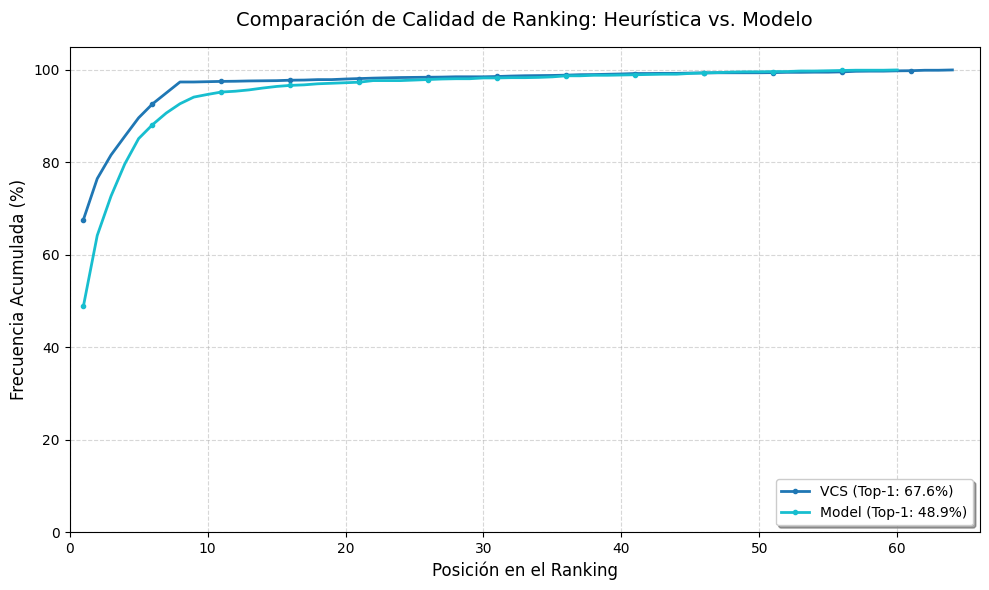

In [55]:
counters = {
    "VCS": vcs_bsg_counter,
    "Model": model_bsg_counter
}

plot_ranking_frequencies(counters)